# **Final Notebook: Hybrid Attention MIL**

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if os.getcwd().endswith("notebooks_final"):
    os.chdir("../")
from src_final.features.local_feature_extractor import WindowFeatureExtractor
from src_final.features.attention_mil_dataset import AttentionMILDataset, mil_collate_fn
from src_final.models.attention_mil import HybridAttentionMIL, run_training, run_training_unbiased
from torch.utils.data import DataLoader

In [2]:
processed_path = "data/processed/landmark_dataframes/"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)#[cols_to_keep]
        pbar.update(1)

df_dict = dict(sorted(df_dict.items()))

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

Loading processed data:  97%|█████████▋| 83/86 [00:02<00:00, 32.60it/s]


In [3]:
# 1. Initialize and Prepare Data
extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5, log_transform=False, include_bimanual=False, exclude_idle=True)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Features: 100%|██████████| 83/83 [00:39<00:00,  2.11it/s]


In [102]:
# load top feature df and combine with aggregated window features
df_top_features = pd.read_csv("data/metrics/top_features_df.csv")
df_top_features['video_id'] = df_window_features['video_id'].unique()

# First Test Only With Simple Train/Validation Splitt

Once parameters adjusted move on to LOSO cross validation

In [189]:
# train val split

validation_surgeon_ids = [23]

df_top_features_train = df_top_features[~df_top_features['video_id'].apply(lambda x: int(x[1]) in validation_surgeon_ids)]
df_top_features_val = df_top_features[df_top_features['video_id'].apply(lambda x: int(x[1]) in validation_surgeon_ids)]

df_window_features_train = df_window_features[~df_window_features['video_id'].apply(lambda x: int(x[1]) in validation_surgeon_ids)]
df_window_features_val = df_window_features[df_window_features['video_id'].apply(lambda x: int(x[1]) in validation_surgeon_ids)]

### Global Feature Scaling and PCA

In [190]:
df_global_features_train = df_top_features_train.copy()
df_global_features_val = df_top_features_val.copy()

In [191]:
pca_global_features = ['num_reversals_Right', 'total_duration_Left', 'nmu_peaks_Right', 'total_path_Right', 'ldlj_smoothness_Left', 'total_angular_path_Right']
additional_global_features = ['velocity_corr']

global_cols = pca_global_features + additional_global_features

df_global_features_train[global_cols] = df_global_features_train[global_cols].astype(float)
df_global_features_val[global_cols] = df_global_features_val[global_cols].astype(float)

scaler = StandardScaler()

df_global_features_train.loc[:, global_cols] = scaler.fit_transform(
    df_global_features_train.loc[:, global_cols]
)

df_global_features_val.loc[:, global_cols] = scaler.transform(
    df_global_features_val.loc[:, global_cols]
)

pca = PCA(n_components=1)

df_global_features_train.loc[:, 'global_feature_pca'] = (
    pca.fit_transform(df_global_features_train[pca_global_features])
)

df_global_features_val.loc[:, 'global_feature_pca'] = (
    pca.transform(df_global_features_val[pca_global_features])
)

global_cols = ['global_feature_pca'] + additional_global_features

### Window Feature Transformation And Scaling

In [192]:
df_window_features_train = df_window_features_train.copy()
df_window_features_val = df_window_features_val.copy()

In [193]:
from sklearn.preprocessing import RobustScaler, StandardScaler, QuantileTransformer
import pandas as pd
import numpy as np

class MILFeatureScaler:
    def __init__(self, feature_cols, log_features=None, method='robust'):
        """
        feature_cols: List of all features to be scaled.
        log_features: List of specific features to apply log(1+x) transformation to.
        method: 'robust', 'quantile', or 'standard'.
        """
        self.feature_cols = feature_cols
        self.log_features = log_features if log_features is not None else []
        self.method = method
        
        if method == 'robust':
            self.scaler = RobustScaler()
        elif method == 'quantile':
            self.scaler = QuantileTransformer(output_distribution='normal', random_state=42)
        else:
            self.scaler = StandardScaler()
            
    def _apply_log(self, df):
        """Internal helper to apply log transformation."""
        df_log = df.copy()
        for col in self.log_features:
            # np.log1p computes ln(1 + x) to handle zeros safely
            df_log[col] = np.log1p(df_log[col])
        return df_log

    def fit(self, df_all_windows):
        """Fit the scaler on training windows after log-transforming subsets."""
        # 1. Apply log transform to the subset
        df_transformed = self._apply_log(df_all_windows[self.feature_cols])
        
        # 2. Extract values and fit the scaler
        X = df_transformed.values
        self.scaler.fit(X)
        print(f"Scaler ({self.method}) fitted on {len(X)} windows with {len(self.log_features)} log-transformed features.")
        
    def transform(self, df_windows):
        """Transform windows for training or inference."""
        # 1. Apply log transform to the subset
        df_transformed = self._apply_log(df_windows[self.feature_cols])
        
        # 2. Transform the features
        X = df_transformed.values
        X_scaled = self.scaler.transform(X)
        
        # 3. Clip for numerical stability in the Neural Net
        X_scaled = np.clip(X_scaled, -5.0, 5.0)
        
        # Create a copy of the original to return, but updated with scaled values
        df_out = df_windows.copy()
        df_out[self.feature_cols] = X_scaled
        return df_out

# --- Implementation Example ---

# Define all features for the model
features_to_use = ['dim_jerk', 'curvature', 'spatial_spread', 'vel_mean', 'vel_p90', 'palm_area_cv', 'ang_vel_mean', 'path_ratio']

# Identify the skewed "physical" features for log transform
log_transform_subset = ['dim_jerk', 'spatial_spread', 'vel_mean', 'vel_p90', 'ang_vel_mean', 'path_ratio']

# Initialize
mil_scaler = MILFeatureScaler(
    feature_cols=features_to_use, 
    log_features=log_transform_subset, 
    method='robust'
)

# Fit on training data
mil_scaler.fit(df_window_features_train)

# Transform sets
train_videos_scaled = mil_scaler.transform(df_window_features_train)
val_videos_scaled = mil_scaler.transform(df_window_features_val)

Scaler (robust) fitted on 61491 windows with 6 log-transformed features.


<Axes: title={'center': 'Dim Jerk Distribution After Scaling'}, ylabel='Frequency'>

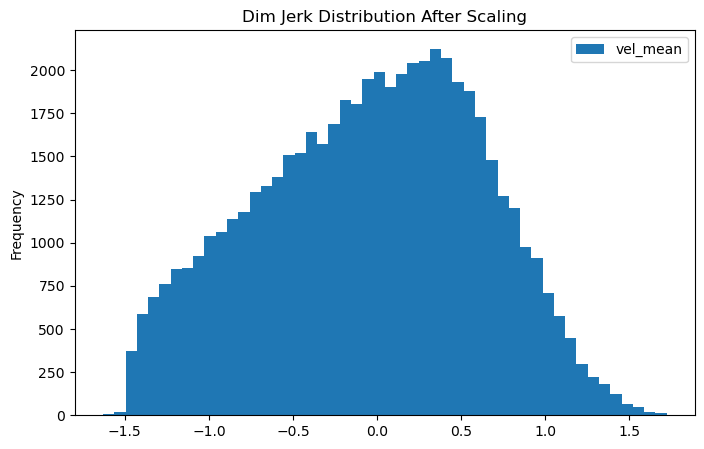

In [96]:
# plot spatial spread distribution after scaling
train_videos_scaled.plot.hist(column='vel_mean', bins=50, figsize=(8, 5), title='Dim Jerk Distribution After Scaling')

In [ ]:
train_videos_scaled[features_to_use].corr()

,dim_jerk,curvature,spatial_spread,vel_mean,vel_p90,palm_area_cv,ang_vel_mean,path_ratio
dim_jerk,1.000000,0.334638,-0.575390,-0.339739,-0.436389,0.057410,0.041051,0.487622
curvature,0.334638,1.000000,-0.650667,-0.666178,-0.622959,-0.339260,-0.345652,0.016562
spatial_spread,-0.575390,-0.650667,1.000000,0.893606,0.909050,0.411074,0.512365,-0.246864
vel_mean,-0.339739,-0.666178,0.893606,1.000000,0.977771,0.567306,0.654977,0.115863
vel_p90,-0.436389,-0.622959,0.909050,0.977771,1.000000,0.530550,0.628704,0.040916
palm_area_cv,0.057410,-0.339260,0.411074,0.567306,0.530550,1.000000,0.585418,0.256180
ang_vel_mean,0.041051,-0.345652,0.512365,0.654977,0.628704,0.585418,1.000000,0.203448
path_ratio,0.487622,0.016562,-0.246864,0.115863,0.040916,0.256180,0.203448,1.000000


# Generate Dataset Loaders

In [97]:
# scale the QRS score as well
score_scaler = StandardScaler()
df_global_features_train['QRS_Overal'] = score_scaler.fit_transform(
    df_global_features_train['QRS_Overal'].values.reshape(-1, 1))

df_global_features_val['QRS_Overal'] = score_scaler.transform(
    df_global_features_val['QRS_Overal'].values.reshape(-1, 1))

In [98]:
window_features = ['dim_jerk', 'curvature', 'spatial_spread', 'vel_mean', 'palm_area_cv'] + ['is_idle']

window_features = ['dim_jerk', 'spatial_spread', 'palm_area_cv', 'path_ratio']# + ['is_idle']
#window_features = ['path_ratio', 'is_idle']
#window_features = ['spatial_spread', 'palm_area_cv', 'dim_jerk', 'curvature'] + ['is_idle']
window_features = ['spatial_spread', 'path_ratio', 'palm_area_cv']

train_dataset = AttentionMILDataset(
    train_videos_scaled,
    df_global_features_train,
    window_features,
    global_cols,
    label_col='QRS_Overal'
)

val_dataset = AttentionMILDataset(
    val_videos_scaled,
    df_global_features_val,
    window_features,
    global_cols,
    label_col='QRS_Overal'
)

Preparing Bags:   0%|          | 0/74 [00:00<?, ?it/s]

Preparing Bags: 100%|██████████| 9/9 [00:00<00:00, 63.26it/s]


In [99]:
train_loader = DataLoader(train_dataset, batch_size=81, shuffle=True, collate_fn=mil_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=mil_collate_fn)

## Attention MIL Training

## Unbiased Training 

**No peeking at test data for model selection!**

2 approaches:

- Fix number of training epochs and adjust hyperparameters for optimal performance

- Inner nested CV and Model selection based on the performance on the held out validation data. final prediction is an average of the best model predictions.

In [194]:
model = HybridAttentionMIL(
    local_dim=len(window_features),
    global_dim=len(global_cols),
    mlp_hidden_dim=8,
    attention_hidden_dim=2,
    dropout=0.0,
    use_feature_extractor=False,
    temperature=0.5
)

_, history = run_training_unbiased(model,
                      train_loader,
                      val_loader,
                      epochs=1000,
                      lr=1e-3,
                      score_scaler=score_scaler,
                      patience=50,
                      verbose=True,
                      avg_window=50,
                      ablation='global_only',
                      train_mae_threshold=4.35)

Starting training (Fixed/Train-based Stopping)...
Epoch | Train Loss | Train MAE  | Test Loss  | Test MAE (Ref)  | LR      
-------------------------------------------------------------------------------------
1     | 38.524     | 45.614     | 26.824     | 41.1471          | 1.0e-03
5     | 38.469     | 45.526     | 26.478     | 41.0000          | 1.0e-03
10    | 38.403     | 45.419     | 26.066     | 40.8168          | 1.0e-03
15    | 38.341     | 45.332     | 25.672     | 40.6360          | 1.0e-03
20    | 38.281     | 45.250     | 25.296     | 40.4587          | 1.0e-03
25    | 38.220     | 45.172     | 24.941     | 40.2872          | 1.0e-03
30    | 38.161     | 45.097     | 24.607     | 40.1259          | 1.0e-03
35    | 38.103     | 45.023     | 24.294     | 39.9768          | 1.0e-03
40    | 38.047     | 44.952     | 24.003     | 39.8364          | 1.0e-03
45    | 37.992     | 44.887     | 23.733     | 39.7031          | 1.0e-03


KeyboardInterrupt: 

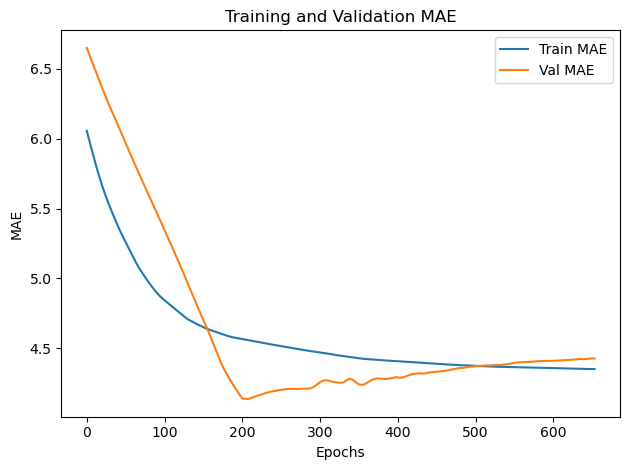

In [81]:
# plot training history
import matplotlib.pyplot as plt

def plot_training_history(history):

    # Plot training and validation MAE
    plt.figure()
    plt.plot(history['train_mae'], label='Train MAE')
    plt.plot(history['test_mae'], label='Val MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.title('Training and Validation MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(pd.DataFrame(history))

Starting training (Fixed/Train-based Stopping)...

[Terminated] Training converged at epoch 208.
Applying weight averaging over the last 10 epochs...
Averaged Model Test MAE: 8.5116 (compared to final epoch 8.5128)
Training Complete. Final Test MAE: 8.5116 at Epoch 208, Train MAE: 4.4401


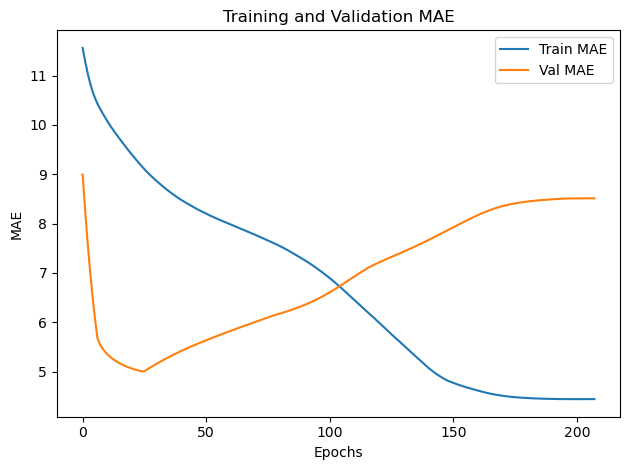

Starting training (Fixed/Train-based Stopping)...

[Terminated] Training converged at epoch 280.
Applying weight averaging over the last 10 epochs...
Averaged Model Test MAE: 8.7897 (compared to final epoch 8.7789)
Training Complete. Final Test MAE: 8.7897 at Epoch 280, Train MAE: 3.9407


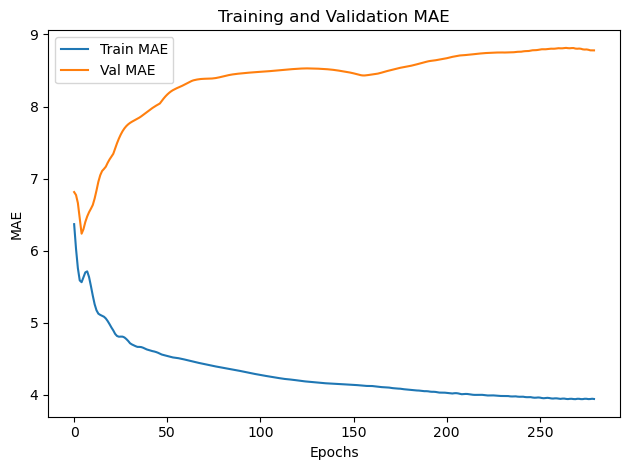

Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 10 epochs...
Averaged Model Test MAE: 8.7714 (compared to final epoch 8.7702)
Training Complete. Final Test MAE: 8.7714 at Epoch 500, Train MAE: 3.9882


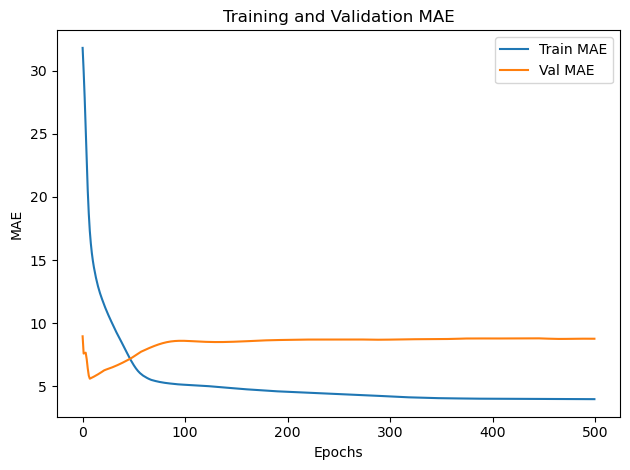

Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 10 epochs...
Averaged Model Test MAE: 8.9911 (compared to final epoch 8.9882)
Training Complete. Final Test MAE: 8.9911 at Epoch 500, Train MAE: 4.0122


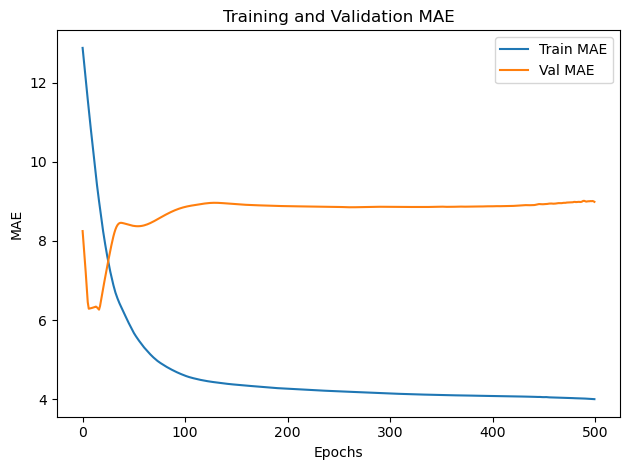

Starting training (Fixed/Train-based Stopping)...

[Terminated] Training converged at epoch 473.
Applying weight averaging over the last 10 epochs...
Averaged Model Test MAE: 8.8577 (compared to final epoch 8.8579)
Training Complete. Final Test MAE: 8.8577 at Epoch 473, Train MAE: 4.1254


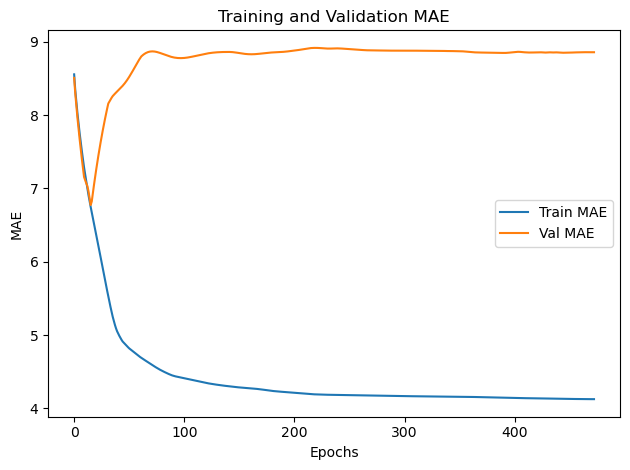

Average Train MAE over 5 runs: 4.0998 ± 0.1810
Average Val MAE over 5 runs: 8.7816 ± 0.1555


In [55]:
train_maes = []
val_maes = []

for i in range(5):
    model = HybridAttentionMIL(
    local_dim=len(window_features),
    global_dim=len(global_cols),
    mlp_hidden_dim=4,
    attention_hidden_dim=4,
    dropout=0.0,
    use_feature_extractor=False,
    temperature=0.025
)

    _, history = run_training_unbiased(model,
                      train_loader,
                      val_loader,
                      epochs=500,
                      lr=5e-3,
                      score_scaler=score_scaler,
                      patience=10,
                      verbose=False,
                      avg_window=10,
                      use_weight_averaging=True,
                      ablation=None)
    
    train_maes.append(history[-1]['train_mae'])
    val_maes.append(history[-1]['test_mae'])
    
    plot_training_history(pd.DataFrame(history))

print(f"Average Train MAE over 5 runs: {np.mean(train_maes):.4f} ± {np.std(train_maes):.4f}")
print(f"Average Val MAE over 5 runs: {np.mean(val_maes):.4f} ± {np.std(val_maes):.4f}")

# keep track of experiment outputs:

test surgeon id: 4
- window features only :  ['spatial_spread', 'palm_area_cv', 'path_ratio'] + ['is_idle']

- results (only mil feats):  
    Average Train MAE over 5 runs: 6.1710 ± 0.2017  
    Average Val MAE over 5 runs: 5.0349 ± 0.7024

- results (hybrid and with jerk feat)   
    Average Train MAE over 5 runs: 4.4393 ± 0.1462  
    Average Val MAE over 5 runs: 5.8000 ± 0.3322

test surgeon id: 5  
- results (only mil feats):
    Average Train MAE over 5 runs: 6.0400 ± 0.1681  
    Average Val MAE over 5 runs: 7.0219 ± 0.3951

test surgeon id: 6
- results (only mil feats): 
    Average Train MAE over 5 runs: 6.1914 ± 0.3458  
    Average Val MAE over 5 runs: 10.0039 ± 0.6964

- results (hybrid feats):   
    Average Train MAE over 5 runs: 4.4714 ± 0.2448  
    Average Val MAE over 5 runs: 2.2745 ± 0.4103
    
```python
mlp_hidden_dim=24,
attention_hidden_dim=16,
dropout=0.05,
patience=100,
verbose=False,
avg_window=100,
use_weight_averaging=True,
ablation='mil_only'
```


I tried using only spatial spread which in my manual window feature exploration proved to be powerfull in explaining the residuals of the baseline ridge model.

## Compute Residuals of Baseline Model

- Evaluate feature correlation to scores and residuals

- train attentionMIL on the resdiduals

In [195]:
from sklearn.linear_model import Ridge

if df_global_features_train['QRS_Overal'].mean() < 40:
    print("Scores not at original scale!!!")

ridge_model = Ridge(alpha=0.5)

ridge_model.fit(df_global_features_train[global_cols], df_global_features_train['QRS_Overal'])

train_resid = df_global_features_train['QRS_Overal'] - ridge_model.predict(df_global_features_train[global_cols])
val_resid = df_global_features_val['QRS_Overal'] - ridge_model.predict(df_global_features_val[global_cols])

print(f"Ridge Train MAE: {np.mean(np.abs(train_resid)):.4f}")
print(f"Ridge Val MAE: {np.mean(np.abs(val_resid)):.4f}")

df_global_features_train['baseline_residuals'] = train_resid.values
df_global_features_val['baseline_residuals'] = val_resid.values

Ridge Train MAE: 4.9114
Ridge Val MAE: 3.1859


In [196]:
# correlation between baseline residuals and original scores
df_global_features_train[['QRS_Overal', 'baseline_residuals']].corr()

,QRS_Overal,baseline_residuals
QRS_Overal,1.000000,0.660195
baseline_residuals,0.660195,1.000000


In [145]:
from scipy.stats import pearsonr

base_agg = train_videos_scaled[window_features + ['video_id']].groupby('video_id').agg(['mean', 'std', 'max'])

#corr of base_agg with baseline residuals
for feat in base_agg.columns:
        feat_values = base_agg[feat].values
        corr, _ = pearsonr(feat_values, df_global_features_train.set_index('video_id').loc[base_agg.index]['baseline_residuals'].values)
        print(f"Feature: {feat}, Corr: {corr:.4f}")
        


Feature: ('spatial_spread', 'mean'), Corr: -0.1717
Feature: ('spatial_spread', 'std'), Corr: -0.2222
Feature: ('spatial_spread', 'max'), Corr: -0.0693
Feature: ('palm_area_cv', 'mean'), Corr: 0.2440
Feature: ('palm_area_cv', 'std'), Corr: 0.1522
Feature: ('palm_area_cv', 'max'), Corr: -0.0640
Feature: ('path_ratio', 'mean'), Corr: 0.2317
Feature: ('path_ratio', 'std'), Corr: 0.2033
Feature: ('path_ratio', 'max'), Corr: 0.1661


In [ ]:
window_features = ['spatial_spread', 'path_ratio', 'palm_area_cv']

train_dataset = AttentionMILDataset(
    train_videos_scaled,
    df_global_features_train,
    window_features,
    global_cols,
    label_col='baseline_residuals'
)

val_dataset = AttentionMILDataset(
    val_videos_scaled,
    df_global_features_val,
    window_features,
    global_cols,
    label_col='baseline_residuals'
)
train_loader = DataLoader(train_dataset, batch_size=81, shuffle=True, collate_fn=mil_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=mil_collate_fn)

Preparing Bags: 100%|██████████| 3/3 [00:00<00:00, 258.93it/s]


In [202]:
model = HybridAttentionMIL(
    local_dim=len(window_features),
    global_dim=len(global_cols),
    mlp_hidden_dim=8,
    attention_hidden_dim=8,
    dropout=0.0,
    use_feature_extractor=False,
    temperature=0.5
)

_, history = run_training_unbiased(model,
                      train_loader,
                      val_loader,
                      epochs=1000,
                      lr=1e-3,
                      score_scaler=None,
                      patience=50,
                      verbose=True,
                      avg_window=50,
                      ablation='mil_only',
                      train_mae_threshold=3.1)

plot_training_history(pd.DataFrame(history))

Starting training (Fixed/Train-based Stopping)...
Epoch | Train Loss | Train MAE  | Test Loss  | Test MAE (Ref)  | LR      
-------------------------------------------------------------------------------------
1     | 37.679     | 4.909     | 10.093     | 3.1752          | 1.0e-03
5     | 37.664     | 4.908     | 10.101     | 3.1765          | 1.0e-03
10    | 37.645     | 4.906     | 10.109     | 3.1778          | 1.0e-03
15    | 37.626     | 4.904     | 10.119     | 3.1793          | 1.0e-03
20    | 37.608     | 4.902     | 10.127     | 3.1807          | 1.0e-03
25    | 37.590     | 4.900     | 10.134     | 3.1818          | 1.0e-03
30    | 37.572     | 4.898     | 10.141     | 3.1828          | 1.0e-03
35    | 37.553     | 4.896     | 10.149     | 3.1842          | 1.0e-03
40    | 37.534     | 4.894     | 10.160     | 3.1859          | 1.0e-03
45    | 37.513     | 4.892     | 10.172     | 3.1877          | 1.0e-03
50    | 37.492     | 4.890     | 10.183     | 3.1894          | 1.0e-0

KeyboardInterrupt: 

In [203]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr
from tqdm import tqdm

# Note need to add more seed control for full reproducibility!!
def run_loso_mil_residual_ensemble(
    df_global,           # df_top_features
    df_windows,          # df_window_features
    window_feature_cols, # ['spatial_spread', 'palm_area_cv', 'dim_jerk', 'is_idle']
    pca_global_cols,     # The 6 metrics for PCA
    additional_global,   # ['velocity_corr']
    n_ensemble=3,        # Initializations per fold
    target_col='QRS_Overal',
    device='cpu',
    seed=42
):
    unique_surgeons = df_global['video_id'].apply(lambda x: int(x[1])).unique()
    
    all_final_preds = []
    all_true_scores = []
    fold_summaries = []

    # 1. Main LOSO Loop
    for surgeon_out in tqdm(unique_surgeons, desc="LOSO Folds"):
        
        # --- A. Split Data ---
        train_mask = df_global['video_id'].apply(lambda x: int(x[1])) != surgeon_out
        test_mask = df_global['video_id'].apply(lambda x: int(x[1])) == surgeon_out
        
        df_g_train = df_global[train_mask].copy()
        df_g_test = df_global[test_mask].copy()
        
        df_w_train = df_windows[df_windows['video_id'].apply(lambda x: int(x[1])) != surgeon_out].copy()
        df_w_test = df_windows[df_windows['video_id'].apply(lambda x: int(x[1])) == surgeon_out].copy()

        # --- B. Global Feature Engineering (Ridge Baseline) ---
        # 1. Scale Global features
        scaler_g = StandardScaler()
        train_scaled = scaler_g.fit_transform(df_g_train[pca_global_cols + additional_global])
        test_scaled = scaler_g.transform(df_g_test[pca_global_cols + additional_global])
        
        # 2. PCA on the subset
        pca = PCA(n_components=1)
        # Assuming PCA features are the first 6 indices
        train_pca = pca.fit_transform(train_scaled[:, :len(pca_global_cols)])
        test_pca = pca.transform(test_scaled[:, :len(pca_global_cols)])

        df_g_train['global_feature_pca'] = train_pca
        df_g_test['global_feature_pca'] = test_pca
        global_cols = ['global_feature_pca'] + additional_global
        
        # 3. Final Ridge Input: [PCA_1, velocity_corr]
        X_ridge_train = np.hstack([train_pca, train_scaled[:, len(pca_global_cols):]])
        X_ridge_test = np.hstack([test_pca, test_scaled[:, len(pca_global_cols):]])
        
        y_train = df_g_train[target_col].values
        y_test = df_g_test[target_col].values
        
        # 4. Fit Ridge and Get Residuals
        ridge = Ridge(alpha=0.5)
        ridge.fit(X_ridge_train, y_train)
        
        ridge_pred_train = ridge.predict(X_ridge_train)
        ridge_pred_test = ridge.predict(X_ridge_test)
        ridge_train_mae = mean_absolute_error(y_train, ridge_pred_train)
        ridge_mae = mean_absolute_error(y_test, ridge_pred_test)
        
        train_residuals = y_train - ridge_pred_train
        df_g_train['baseline_residuals'] = train_residuals
        test_residuals = y_test - ridge_pred_test
        df_g_test['baseline_residuals'] = test_residuals

        # --- C. MIL Feature Scaling (Local Windows) ---
        window_scale_features = window_feature_cols.copy()
       #window_scale_features.remove('is_idle')  # Exclude binary feature from scaling
        mil_scaler = MILFeatureScaler(
            feature_cols=window_scale_features, 
            log_features=['spatial_spread'], #'dim_jerk'
            #method='robust'
        )
        mil_scaler.fit(df_w_train)
        w_train_scaled = mil_scaler.transform(df_w_train)
        w_test_scaled = mil_scaler.transform(df_w_test)

        # Prepare MIL Datasets
        train_ds = AttentionMILDataset(w_train_scaled, df_g_train, window_feature_cols, 
                                       global_cols, label_col='baseline_residuals')
        test_ds = AttentionMILDataset(w_test_scaled, df_g_test, window_feature_cols, 
                                      global_cols, label_col='baseline_residuals')
        
        train_loader = DataLoader(train_ds, batch_size=81, shuffle=True, collate_fn=mil_collate_fn)
        test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=mil_collate_fn)

        # --- D. MIL Ensemble Training (Stage 2) ---
        fold_mil_preds = []
        fold_mil_train_preds = []
        
        for i in range(n_ensemble):
            seed_i = seed + i
            torch.manual_seed(seed_i)

            # Re-initialize model each time
            model = HybridAttentionMIL(
                local_dim=len(window_feature_cols),
                global_dim=2, # PCA + Velocity Corr
                mlp_hidden_dim=8,
                attention_hidden_dim=8,
                dropout=0,
                use_feature_extractor=False,
                temperature=0.5,
            ).to(device)
            
            # Train model on residuals
            best_model, _ = run_training_unbiased(
                model, train_loader, test_loader, 
                epochs=600, lr=1e-3,
                patience=50, avg_window=50, 
                verbose=False, ablation='mil_only',
                train_mae_threshold=ridge_train_mae-0.45
            )
            
            # Predict residual
            best_model.eval()
            with torch.no_grad():
                # Get PER-SAMPLE predictions for Train
                current_train_preds = []
                
                train_pred_loader = DataLoader(train_ds, batch_size=1, shuffle=False, collate_fn=mil_collate_fn)
                test_pred_loader = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=mil_collate_fn)
                
                for b_bags, b_globs, _, _ in train_pred_loader:
                    for j in range(len(b_bags)): # Changed i to j
                        p, _ = best_model(b_bags[j].to(device), b_globs[j].unsqueeze(0).to(device), ablation='mil_only')
                        current_train_preds.append(p.item())
                fold_mil_train_preds.append(np.array(current_train_preds))

                # Get PER-SAMPLE predictions for Test
                current_test_preds = []
                for b_bags, b_globs, _, _ in test_pred_loader:
                    for j in range(len(b_bags)): # Changed i to j
                        p, _ = best_model(b_bags[j].to(device), b_globs[j].unsqueeze(0).to(device), ablation='mil_only')
                        current_test_preds.append(p.item())
                fold_mil_preds.append(np.array(current_test_preds))
        
        # Average the 3 residual predictions
        avg_mil_train_residual = np.mean(fold_mil_train_preds, axis=0)
        avg_mil_residual = np.mean(fold_mil_preds, axis=0)
        
        # Final prediction = Ridge Baseline + MIL Correction
        final_prediction_train = ridge_pred_train + avg_mil_train_residual
        final_prediction = ridge_pred_test + avg_mil_residual
        
        all_final_preds.extend(final_prediction)
        all_true_scores.extend(y_test)
        
        fold_test_mae = mean_absolute_error(y_test, final_prediction)
        fold_train_mae = mean_absolute_error(y_train, final_prediction_train)
        fold_summaries.append({
            'Surgeon': surgeon_out,
            'Ridge_MAE': ridge_mae,
            'Test_MAE': fold_test_mae,
            'Train_MAE': fold_train_mae
        })

        print(f"\nSurgeon {surgeon_out} | Train MAE: {fold_train_mae:.4f} | Test MAE: {fold_test_mae:.4f} | Ridge MAE: {ridge_mae:.4f}\n")

    # --- E. Final Results ---
    results_df = pd.DataFrame(fold_summaries)
    overall_mae = mean_absolute_error(all_true_scores, all_final_preds)
    overall_std = np.std(np.abs(np.array(all_true_scores) - np.array(all_final_preds)))
    overall_r2 = r2_score(all_true_scores, all_final_preds)
    
    print(f"\nFinal LOSO Results:")
    print(f"Overall MAE: {overall_mae:.4f}")
    print(f"Overall Std: {overall_std:.4f}")
    print(f"Overall R2: {overall_r2:.4f}")
    
    return results_df, all_true_scores, all_final_preds

In [56]:
window_features = ['spatial_spread', 'palm_area_cv', 'path_ratio']

results_df, true_scores, final_preds = run_loso_mil_residual_ensemble(df_top_features,
                                                                      df_window_features,
                                                                      window_features,
                                                                      pca_global_features,
                                                                      additional_global_features,
                                                                      n_ensemble=3,
                                                                      target_col='QRS_Overal',
                                                                      device='cpu')

LOSO Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Scaler (robust) fitted on 62910 windows with 1 log-transformed features.


Preparing Bags: 100%|██████████| 3/3 [00:00<00:00, 293.92it/s]


Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 6.7526 (compared to final epoch 6.6580)
Training Complete. Final Test MAE: 6.7526 at Epoch 466, Train MAE: 4.3681
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 6.7435 (compared to final epoch 6.3455)
Training Complete. Final Test MAE: 6.7435 at Epoch 299, Train MAE: 4.4011
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 6.6885 (compared to final epoch 6.5609)
Training Complete. Final Test MAE: 6.6885 at Epoch 447, Train MAE: 4.3827


LOSO Folds:   4%|▎         | 1/28 [01:01<27:37, 61.38s/it]

...


Surgeon 28 | Train MAE: 4.6220 | Test MAE: 0.2629 | Ridge MAE: 1.5833

Scaler (robust) fitted on 62127 windows with 1 log-transformed features.


Preparing Bags: 100%|██████████| 3/3 [00:00<00:00, 325.38it/s]


Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 2.3741 (compared to final epoch 2.3526)
Training Complete. Final Test MAE: 2.3741 at Epoch 432, Train MAE: 4.5641
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 3.4312 (compared to final epoch 3.4907)
Training Complete. Final Test MAE: 3.4312 at Epoch 315, Train MAE: 4.5853
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 2.7715 (compared to final epoch 2.6190)
Training Complete. Final Test MAE: 2.7715 at Epoch 367, Train MAE: 4.5637


LOSO Folds: 100%|██████████| 28/28 [24:29<00:00, 52.47s/it]


Surgeon 29 | Train MAE: 4.5435 | Test MAE: 2.8590 | Ridge MAE: 3.4358


Final LOSO Results:
Overall MAE: 4.7426
Overall Std: 3.6854
Overall R2: 0.5836


In [59]:
# spearman and pearson correlation between true scores and final preds
spearman_corr, _ = spearmanr(true_scores, final_preds)
pearson_corr, _ = pearsonr(true_scores, final_preds)    
print(f"Spearman Correlation: {spearman_corr:.4f}")
print(f"Pearson Correlation: {pearson_corr:.4f}")

Spearman Correlation: 0.7850
Pearson Correlation: 0.7649


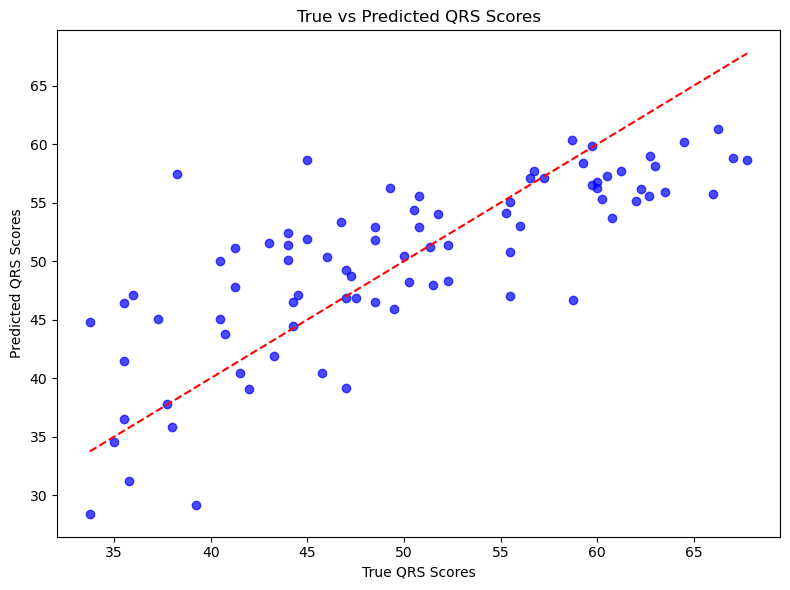

In [60]:
# plot true vs predicted scores
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(true_scores, final_preds, color='blue', alpha=0.7)
plt.plot([min(true_scores), max(true_scores)], [min(true_scores), max(true_scores)], color='red', linestyle='--')  # Line y=x for reference
plt.xlabel('True QRS Scores')
plt.ylabel('Predicted QRS Scores')
plt.title('True vs Predicted QRS Scores')
plt.tight_layout()

## Ablation study

1. Train model on the residuals but now with the same 2 global features that I used in the ridge model. If this turns out better than ridge only, then there is non-linearity that the linear model just can't capture. If better than ridge + local trained model, then the local signal is not very strong!

2. If the above is better than baseline ridge it makes sense to also train a model on the residuals with both the 2 global and the 3 local features again.



In [87]:
# train thresh 0.4 instead of 0.35 => no improvement
# NOW ablation: ablation, globals only instead of mil only 

results_df2, true_scores2, final_preds2 = run_loso_mil_residual_ensemble(df_top_features,
                                                                      df_window_features,
                                                                      window_features,
                                                                      pca_global_features,
                                                                      additional_global_features,
                                                                      n_ensemble=3,
                                                                      target_col='QRS_Overal',
                                                                      device='cpu')

LOSO Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Scaler (robust) fitted on 62910 windows with 1 log-transformed features.


Preparing Bags: 100%|██████████| 3/3 [00:00<00:00, 157.13it/s]


Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 8.4531 (compared to final epoch 8.4632)
Training Complete. Final Test MAE: 8.4531 at Epoch 284, Train MAE: 4.3807
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 8.4554 (compared to final epoch 8.4750)
Training Complete. Final Test MAE: 8.4554 at Epoch 192, Train MAE: 4.3793
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 8.5205 (compared to final epoch 8.5310)
Training Complete. Final Test MAE: 8.5205 at Epoch 541, Train MAE: 4.3664


LOSO Folds:   4%|▎         | 1/28 [00:40<18:07, 40.29s/it]

...


Surgeon 28 | Train MAE: 4.6360 | Test MAE: 1.0116 | Ridge MAE: 1.5833

Scaler (robust) fitted on 62127 windows with 1 log-transformed features.


Preparing Bags: 100%|██████████| 3/3 [00:00<00:00, 154.62it/s]


Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 3.9500 (compared to final epoch 3.9912)
Training Complete. Final Test MAE: 3.9500 at Epoch 324, Train MAE: 4.5713
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 4.2674 (compared to final epoch 4.3243)
Training Complete. Final Test MAE: 4.2674 at Epoch 600, Train MAE: 4.6300
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 4.1259 (compared to final epoch 4.1852)
Training Complete. Final Test MAE: 4.1259 at Epoch 450, Train MAE: 4.5728


LOSO Folds: 100%|██████████| 28/28 [26:22<00:00, 56.53s/it]


Surgeon 29 | Train MAE: 4.5860 | Test MAE: 4.1145 | Ridge MAE: 3.4358


Final LOSO Results:
Overall MAE: 4.8112
Overall Std: 3.8234
Overall R2: 0.5641


In [89]:
# train with no ablation on the residuals of the basline model

results_df3, true_scores3, final_preds3 = run_loso_mil_residual_ensemble(df_top_features,
                                                                      df_window_features,
                                                                      window_features,
                                                                      pca_global_features,
                                                                      additional_global_features,
                                                                      n_ensemble=3,
                                                                      target_col='QRS_Overal',
                                                                      device='cpu')

LOSO Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Scaler (robust) fitted on 62910 windows with 1 log-transformed features.


Preparing Bags: 100%|██████████| 3/3 [00:00<00:00, 144.38it/s]


Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 8.4008 (compared to final epoch 8.3928)
Training Complete. Final Test MAE: 8.4008 at Epoch 148, Train MAE: 4.3921
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 8.3970 (compared to final epoch 8.3919)
Training Complete. Final Test MAE: 8.3970 at Epoch 240, Train MAE: 4.3808
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 8.3133 (compared to final epoch 8.2949)
Training Complete. Final Test MAE: 8.3133 at Epoch 235, Train MAE: 4.3977


LOSO Folds:   4%|▎         | 1/28 [00:57<25:54, 57.57s/it]

...


Surgeon 28 | Train MAE: 4.6456 | Test MAE: 1.0178 | Ridge MAE: 1.5833

Scaler (robust) fitted on 62127 windows with 1 log-transformed features.


Preparing Bags: 100%|██████████| 3/3 [00:00<00:00, 278.00it/s]


Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 4.1280 (compared to final epoch 4.2860)
Training Complete. Final Test MAE: 4.1280 at Epoch 136, Train MAE: 4.5953
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 3.9378 (compared to final epoch 4.0076)
Training Complete. Final Test MAE: 3.9378 at Epoch 237, Train MAE: 4.5800
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 4.1875 (compared to final epoch 4.2566)
Training Complete. Final Test MAE: 4.1875 at Epoch 415, Train MAE: 4.5801


LOSO Folds: 100%|██████████| 28/28 [21:11<00:00, 45.42s/it]


Surgeon 29 | Train MAE: 4.5641 | Test MAE: 4.0844 | Ridge MAE: 3.4358


Final LOSO Results:
Overall MAE: 4.8750
Overall Std: 3.8450
Overall R2: 0.5551


**basline ridge perf:** 
R: 0.7560 | MAE: 5.1521 | MAE STD: 3.8107 | R2: 0.5260 | Adj R2: 0.5080

**ridge + attention mlp on residuals using 3 local features:**      
Overall MAE: 4.7426     
Overall Std: 3.6854     
Overall R2: 0.5836      

**ridge + simple MLP with same features trained on residuals:**     
Overall MAE: 4.8112     
Overall Std: 3.8234     
Overall R2: 0.5641      

local better:		1 1 1 1 1 1 1 1 1 1 1   
vs  
global better:		1 1 1 1 1 1 1 1 1 1 1   

**ridge + both trained on residuals:**  
Overall MAE: 4.8750     
Overall Std: 3.8450     
Overall R2: 0.5551      


How to frame this for "Results & Discussion"   

This is actually a very sophisticated point to make in a thesis. You can argue that Modularity beats Fusion in small-sample surgical data.  

Modular Approach (Your 4.74 winner): You use a Linear Model for Global metrics and an Attention model for Local metrics. This acts as a form of "Manual Feature Selection" that prevents the neural network from getting confused.  

Fusion Approach (The 4.87 dip): You let the neural network handle everything. On a large dataset (N=10,000), the network would eventually figure out how to balance them. On N=84, it just gets "noisy."    

Summary of the "Champion" Model 
Since your best result comes from the Local-Only features being fed into the MIL to predict Ridge residuals, your final prediction formula is essentially:  

Skill = Ridge(Globals) + AttentionMIL(LocalWindows) 

This is a Residual Boosting architecture. It’s elegant, it’s interpretable, and most importantly, it’s the most accurate.   




### Just some debugging observations regarding the alphas and corresponding feature window:

these are the distribution of the window_features = ['spatial_spread', 'path_ratio', 'palm_area_cv'] of the largest alpha 

               0          1          2
count  74.000000  74.000000  74.000000
mean   -0.838218   1.682293   1.382281
std     0.410920   0.980563   0.677347
min    -1.878727  -0.068519  -0.402271
25%    -1.120980   1.001627   1.064649
50%    -0.754276   1.591387   1.399794
75%    -0.586479   2.138858   1.685760
max     0.005034   4.242283   3.391244


and this is the distribution of alphas for one sample:
                0
count  667.000000
mean     0.001499
std      0.002265
min      0.000005
25%      0.000062
50%      0.000659
75%      0.002141
max      0.023097

and this is the same distribution for a different train test splitt:
               0          1          2
count  74.000000  74.000000  74.000000
mean   -0.190576   1.397389   1.803699
std     0.663621   0.732474   0.708602
min    -1.171073  -0.629205  -0.333255
25%    -0.531543   1.163474   1.525046
50%    -0.322640   1.421937   1.797752
75%    -0.053911   1.791857   2.237524
max     2.304796   2.851575   3.446003

looks quite healthy doesn't it?

In [204]:
window_features = ['spatial_spread', 'palm_area_cv', 'path_ratio']

_, _, _ = run_loso_mil_residual_ensemble(df_top_features,
                                        df_window_features,
                                        window_features,
                                        pca_global_features,
                                        additional_global_features,
                                        n_ensemble=3,
                                        target_col='QRS_Overal',
                                        device='cpu')

LOSO Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Scaler (robust) fitted on 62910 windows with 1 log-transformed features.


Preparing Bags: 100%|██████████| 3/3 [00:00<00:00, 241.32it/s]


Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 5.9226 (compared to final epoch 5.8660)
Training Complete. Final Test MAE: 5.9226 at Epoch 584, Train MAE: 4.2543
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 6.3355 (compared to final epoch 6.2180)
Training Complete. Final Test MAE: 6.3355 at Epoch 484, Train MAE: 4.2636
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 6.0347 (compared to final epoch 5.7823)
Training Complete. Final Test MAE: 6.0347 at Epoch 428, Train MAE: 4.3095


LOSO Folds:   4%|▎         | 1/28 [01:17<34:43, 77.16s/it]

...


Surgeon 28 | Train MAE: 4.5323 | Test MAE: 0.7037 | Ridge MAE: 1.5833

Scaler (robust) fitted on 62127 windows with 1 log-transformed features.


Preparing Bags: 100%|██████████| 3/3 [00:00<00:00, 281.35it/s]


Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 3.9617 (compared to final epoch 4.1334)
Training Complete. Final Test MAE: 3.9617 at Epoch 466, Train MAE: 4.5289
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 1.8205 (compared to final epoch 1.7762)
Training Complete. Final Test MAE: 1.8205 at Epoch 552, Train MAE: 4.4664
Starting training (Fixed/Train-based Stopping)...
Applying weight averaging over the last 50 epochs...
Averaged Model Test MAE: 3.8766 (compared to final epoch 3.9199)
Training Complete. Final Test MAE: 3.8766 at Epoch 399, Train MAE: 4.4840


LOSO Folds: 100%|██████████| 28/28 [1:55:38<00:00, 247.79s/it]


Surgeon 29 | Train MAE: 4.4376 | Test MAE: 2.9468 | Ridge MAE: 3.4358


Final LOSO Results:
Overall MAE: 4.7608
Overall Std: 3.4972
Overall R2: 0.5972
